In [1]:
#hide
import sys
!{sys.executable} -m pip install -U fastbook -q

In [3]:
#hide
from fastbook import *
from fastai.vision.widgets import *

Load learner

In [13]:
path = Path()
learn_inf = load_learner(path/'six_or_seven.pkl')

/home/yuebi/miniforge3/envs/fastai_py312/lib/python3.12/site-packages/fastai/learner.py:456: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [4]:
#hide_output
btn_upload = widgets.FileUpload()
btn_upload

FileUpload(value={}, description='Upload')

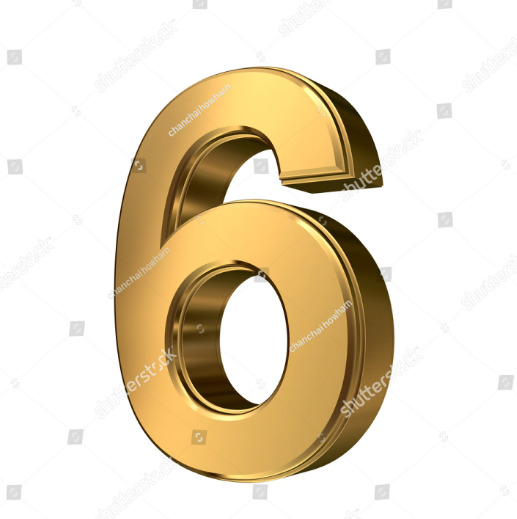

In [9]:
#hide
btn_upload = SimpleNamespace(data = ['images/six.jpg'])

img = PILImage.create(btn_upload.data[-1])

In [10]:
#hide_output
out_pl = widgets.Output()
out_pl.clear_output()
with out_pl:
    display(img.to_thumb(128,128))

out_pl

Output()

In [26]:
#hide_output
model = learn_inf.model.eval()

def preprocess(img):
    t = tensor(img.convert('L').resize((28,28))).float()/255
    if t.mean() > 0.5:
        t = 1-t
    return t.view(1,28*28)

def predict(img):
    with torch.no_grad():
        p = model(preprocess(img)).sigmoid().item()
    return ('6' if p>0.5 else '7', p)
    

In [32]:
#hide_output
p = predict(img)

lbl_pred = widgets.Label()
lbl_prob = p[1] if p[0] == '6' else 1 - p[1]
lbl_pred.value = f'Prediction: {p[0]}; Probability: {lbl_prob:.04f}'
lbl_pred

Label(value='Prediction: 6; Probability: 0.6565')

In [25]:
#hide_output
btn_run = widgets.Button(description='Classify')
btn_run

Button(description='Classify', style=ButtonStyle())

In [46]:
def on_click_classify(change):
    img = PILImage.create(btn_upload.data[-1])
    out_pl.clear_output()
    with out_pl:
         display(img.to_thumb(128,128))
    p = predict(img)
    lbl_prob = p[1] if p[0] == '6' else 1 - p[1]
    print('oamfda')
    lbl_pred.value = f'Prediction: {p[0]}; Probability: {lbl_prob:.04f}'

btn_run.on_click(on_click_classify)

In [47]:
#hide
btn_upload = widgets.FileUpload()

In [48]:
#hide_output
VBox([widgets.Label('Select your image!'),
     btn_upload, btn_run, out_pl, lbl_pred])